In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler
from pmdarima import auto_arima
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [ ]:
ticker = "AAPL"
data = yf.download(ticker, start="2022-01-01", end="2025-01-01")

# Обработка мультииндекса в столбцах
if isinstance(data.columns, pd.MultiIndex):
    data.columns = ['_'.join(col).strip() for col in data.columns.values]

C:\Users\pppp\AppData\Local\Temp\ipykernel_5488\1384476239.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2022-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


In [ ]:
# Первичный анализ
print("\nИнформация о данных:")
print(data.info())
print("\nОписательная статистика:")
print(data.describe())


Информация о данных:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 753 entries, 2022-01-03 to 2024-12-31
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Close_AAPL   753 non-null    float64
 1   High_AAPL    753 non-null    float64
 2   Low_AAPL     753 non-null    float64
 3   Open_AAPL    753 non-null    float64
 4   Volume_AAPL  753 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 35.3 KB
None

Описательная статистика:
       Close_AAPL   High_AAPL    Low_AAPL   Open_AAPL   Volume_AAPL
count  753.000000  753.000000  753.000000  753.000000  7.530000e+02
mean   176.563680  178.241648  174.682379  176.372534  6.808211e+07
std     29.570502   29.496069   29.519707   29.503022  2.838205e+07
min    123.421249  126.136083  122.582119  124.398582  2.323470e+07
25%    153.871704  155.543787  151.620135  153.320687  4.871410e+07
50%    171.708878  172.716901  169.960880  171.413742  6.219900e+07
75%

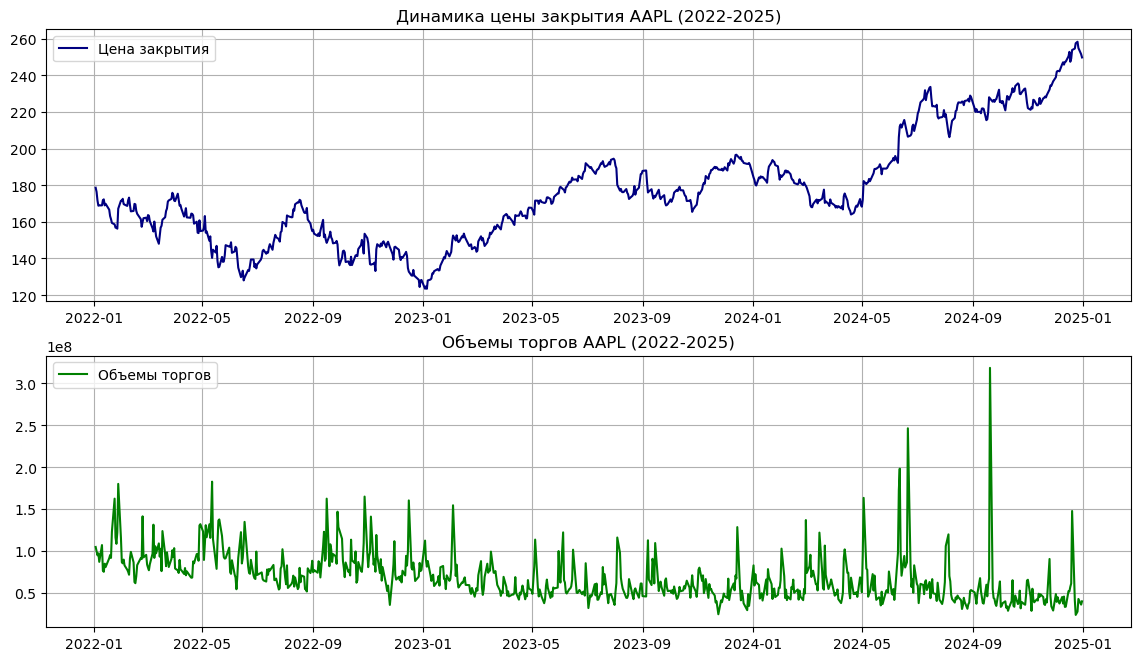

In [ ]:
plt.figure(figsize=(14, 12))

# График цены закрытия
plt.subplot(3, 1, 1)
plt.plot(data['Close_AAPL'], label='Цена закрытия', color='navy')
plt.title('Динамика цены закрытия AAPL (2022-2025)')
plt.grid(True)
plt.legend()

# График объемов торгов
plt.subplot(3, 1, 2)
plt.plot(data['Volume_AAPL'], label='Объемы торгов', color='green')
plt.title('Объемы торгов AAPL (2022-2025)')
plt.grid(True)
plt.legend()

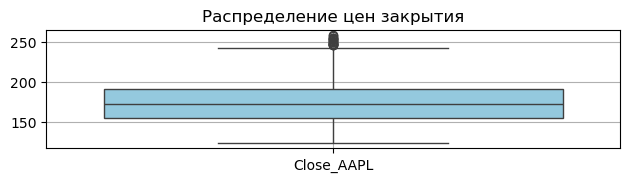

In [ ]:
# Boxplot распределения цен
plt.subplot(3, 1, 3)
sns.boxplot(data=data[['Close_AAPL']], color='skyblue')
plt.title('Распределение цен закрытия')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
stl = STL(data['Close_AAPL'], period=63, robust=True)
res = stl.fit()

def check_stationarity(series, alpha=0.05):
    # ADF тест
    adf_result = adfuller(series.dropna())
    print(f"ADF тест:\nСтатистика: {adf_result[0]:.4f}\nP-значение: {adf_result[1]:.4f}")

    # KPSS тест
    kpss_result = kpss(series.dropna(), regression='c')
    print(f"\nKPSS тест:\nСтатистика: {kpss_result[0]:.4f}\nP-значение: {kpss_result[1]:.4f}")

print("Проверка стационарности исходного ряда:")
check_stationarity(data['Close_AAPL'])
print("\nПроверка стационарности остатков STL:")
check_stationarity(res.resid)

Проверка стационарности исходного ряда:
ADF тест:
Статистика: -0.1514
P-значение: 0.9441

KPSS тест:
Статистика: 3.1096
P-значение: 0.0100

Проверка стационарности остатков STL:
ADF тест:
Статистика: -5.6664
P-значение: 0.0000

KPSS тест:
Статистика: 0.0404
P-значение: 0.1000


C:\Users\pppp\AppData\Local\Temp\ipykernel_5488\3669788072.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c')
C:\Users\pppp\AppData\Local\Temp\ipykernel_5488\3669788072.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c')


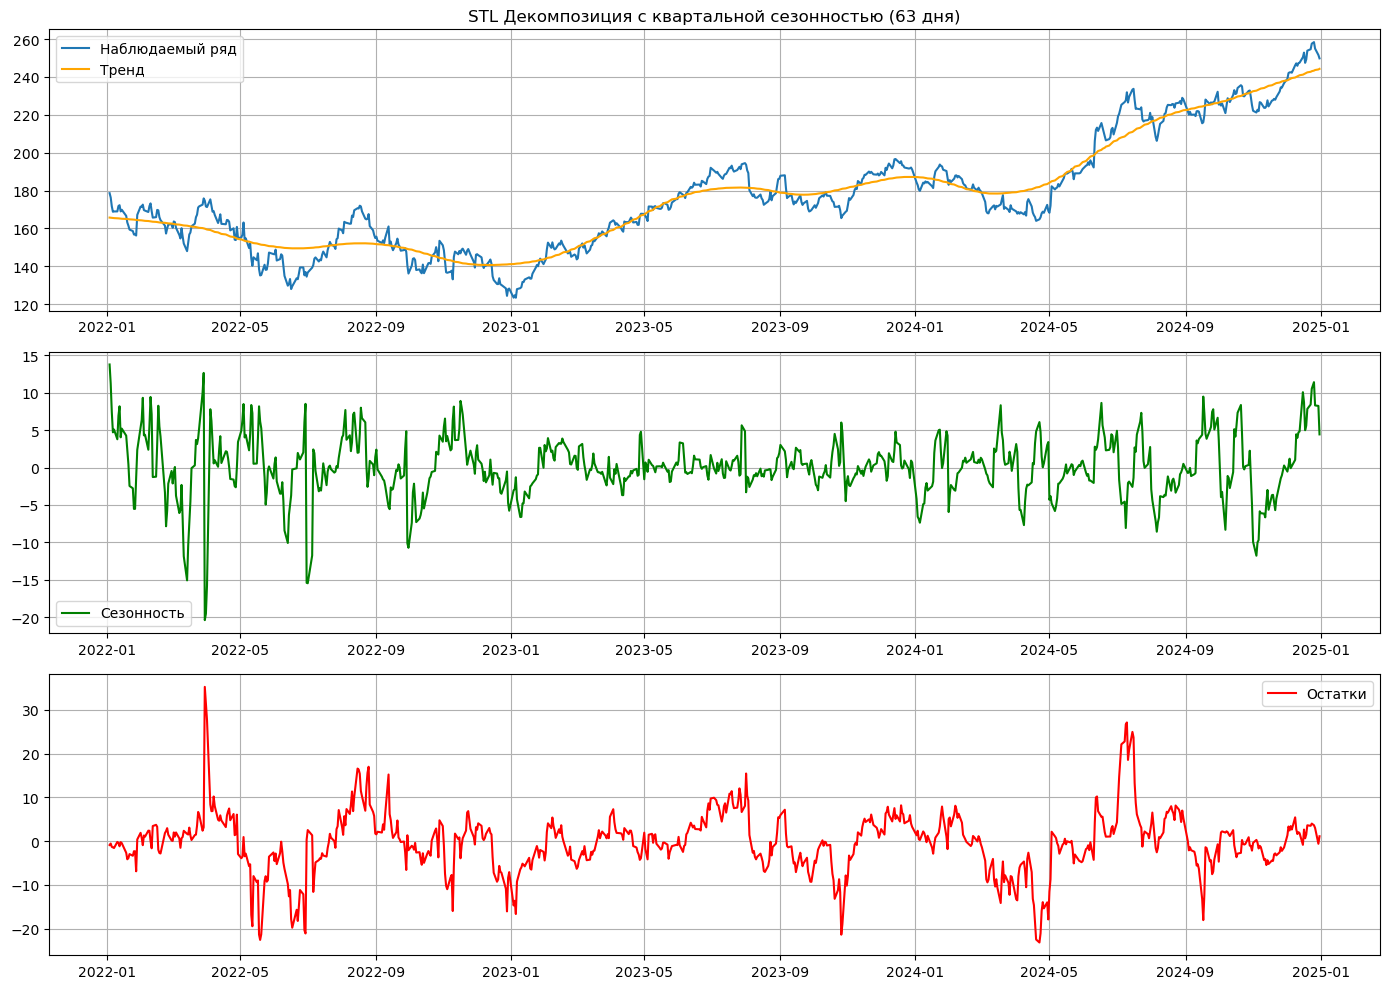

In [ ]:

# Визуализация STL декомпозиции
plt.figure(figsize=(14, 10))

plt.subplot(3, 1, 1)
plt.plot(res.observed, label='Наблюдаемый ряд')
plt.plot(res.trend, label='Тренд', color='orange')
plt.legend()
plt.title('STL Декомпозиция с квартальной сезонностью (63 дня)')
plt.grid(True)

plt.subplot(3, 1, 2)
plt.plot(res.seasonal, label='Сезонность', color='green')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 3)
plt.plot(res.resid, label='Остатки', color='red')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Анализ сезонной компоненты
seasonal = res.seasonal
resid = res.resid

# Расчет амплитуды сезонности
seasonal_amplitude = seasonal.max() - seasonal.min()
peak_to_peak = f"Полная амплитуда сезонности: {seasonal_amplitude:.2f} пунктов"

# Среднее абсолютное отклонение сезонности
seasonal_mad = np.mean(np.abs(seasonal - seasonal.mean()))
mad_info = f"Среднее отклонение сезонности: ±{seasonal_mad:.2f} пунктов"

# Доминирующий период сезонности
fft = np.fft.fft(seasonal)
freqs = np.fft.fftfreq(len(seasonal))
dominant_freq = freqs[np.argmax(np.abs(fft)[1:]) + 1]
dominant_period = int(1/dominant_freq)
period_info = f"Доминирующий период: {dominant_period} дней"

# Анализ остатков
resid_std = resid.std()
resid_metrics = f"Остатки: σ={resid_std:.2f}, диапазон [{resid.min():.2f}, {resid.max():.2f}]"

# Проверка нормальности остатков
from scipy.stats import shapiro
_, p_value = shapiro(resid)
normality = "Остатки нормально распределены" if p_value > 0.05 else "Остатки НЕ нормальны"
print("\nАнализ сезонности STL-декомпозиции:")
print("1.", peak_to_peak)
print("2.", mad_info)
print("3.", period_info)
print("4.", resid_metrics)
print("5.", normality)
print(f"p-value теста на нормальность: {p_value:.4f}")


Анализ сезонности STL-декомпозиции:
1. Полная амплитуда сезонности: 34.21 пунктов
2. Среднее отклонение сезонности: ±2.90 пунктов
3. Доминирующий период: 68 дней
4. Остатки: σ=7.00, диапазон [-23.16, 35.22]
5. Остатки НЕ нормальны
p-value теста на нормальность: 0.0000


In [ ]:
# Проверка на аддитивность/мультипликативность
seasonal_amplitude = res.seasonal.max() - res.seasonal.min()
print(f"\nАмплитуда сезонности: {float(seasonal_amplitude):.2f}")

# Проверка дисперсии
split = len(data) // 2
part1 = data['Close_AAPL'].iloc[:split]
part2 = data['Close_AAPL'].iloc[split:]

var1 = np.var(part1.values)
var2 = np.var(part2.values)
print(f"\nДисперсия первой половины: {var1:.2f}")
print(f"Дисперсия второй половины: {var2:.2f}")

# Тест Левена
from scipy.stats import levene
levene_test = levene(part1.values, part2.values)
p_value = float(levene_test.pvalue)
print(f"\nТест Левена (p-value): {p_value:.4f}")
print("Дисперсия постоянна" if p_value > 0.05 else "Дисперсия НЕ постоянна")


Амплитуда сезонности: 34.21

Дисперсия первой половины: 205.74
Дисперсия второй половины: 588.38

Тест Левена (p-value): 0.0000
Дисперсия НЕ постоянна


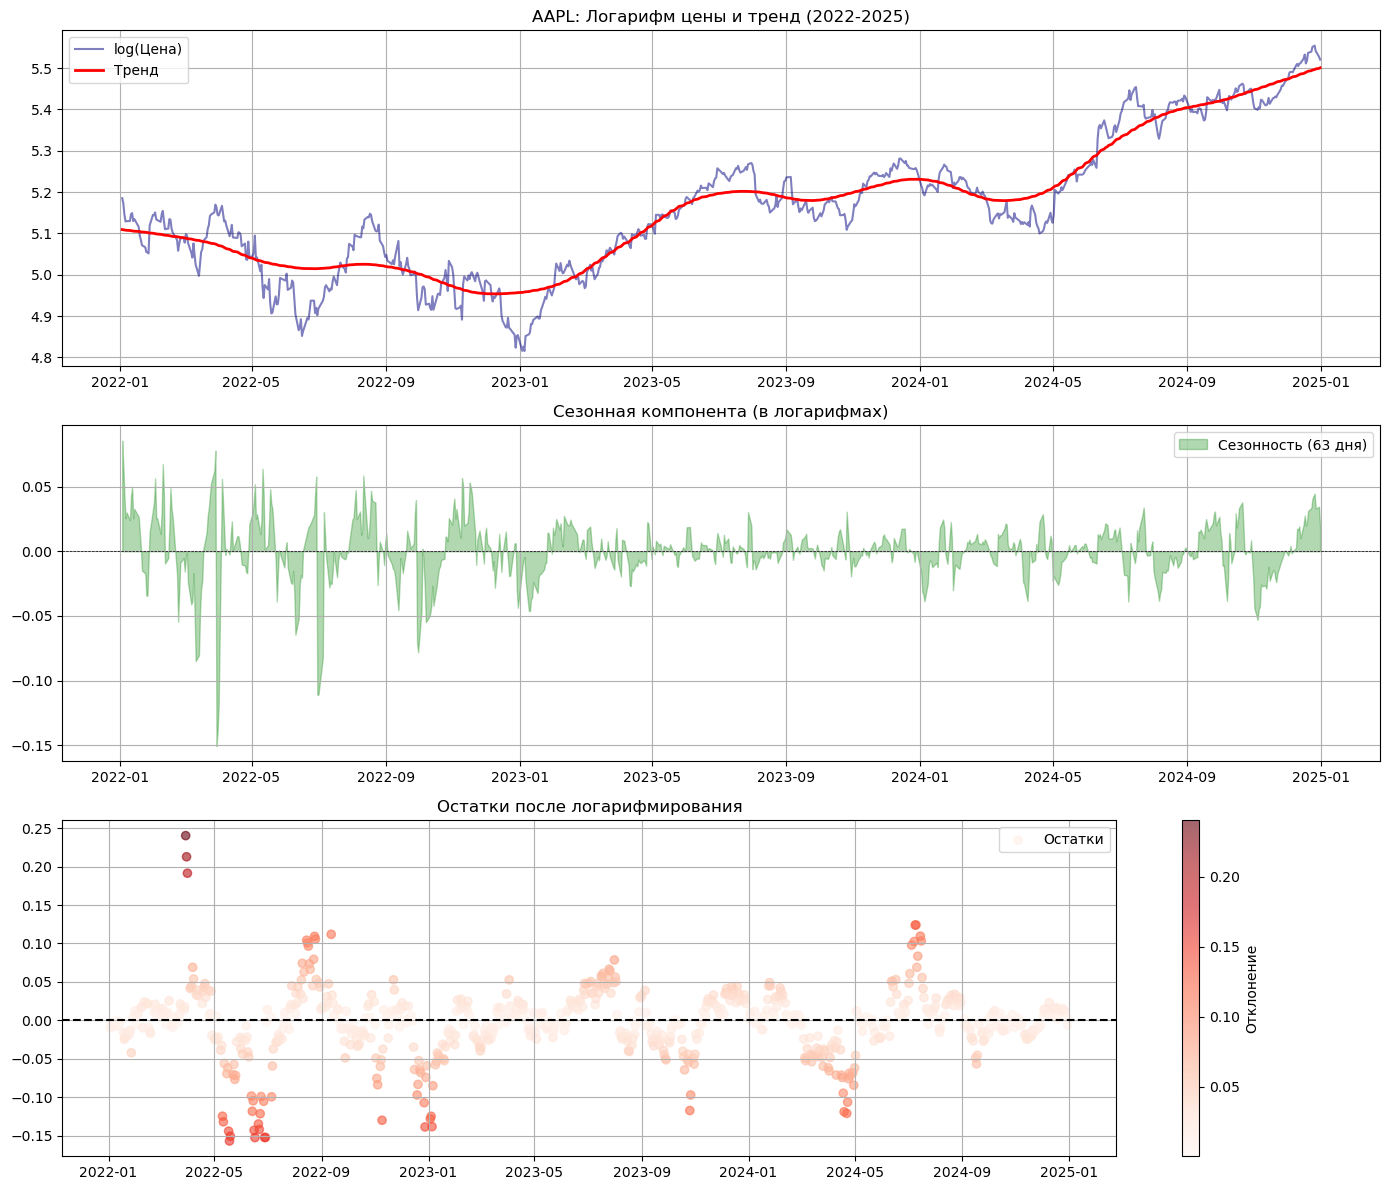

In [ ]:
# 1. Логарифмируем данные
data['Log_Close'] = np.log(data['Close_AAPL'])

# 2. Новая декомпозиция
stl_log = STL(data['Log_Close'], period=63, robust=True)
res_log = stl_log.fit()

# 3. Визуализация для логарифмированных данных
plt.figure(figsize=(14, 12))

plt.subplot(3, 1, 1)
plt.plot(res_log.observed, label='log(Цена)', color='navy', alpha=0.5)
plt.plot(res_log.trend, label='Тренд', color='red', linewidth=2)
plt.title('AAPL: Логарифм цены и тренд (2022-2025)')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 2)
plt.fill_between(res_log.seasonal.index,
                res_log.seasonal,
                color='green',
                alpha=0.3,
                label='Сезонность (63 дня)')
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
plt.title('Сезонная компонента (в логарифмах)')
plt.legend()
plt.grid(True)

plt.subplot(3, 1, 3)
plt.scatter(res_log.resid.index,
           res_log.resid,
           c=np.abs(res_log.resid),
           cmap='Reds',
           alpha=0.6,
           label='Остатки')
plt.colorbar(label='Отклонение')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Остатки после логарифмирования')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Анализ сезонной компоненты после логарифмирования
seasonal_log = res_log.seasonal
resid_log = res_log.resid

# Расчет амплитуды сезонности в логарифмах
seasonal_amplitude_log = seasonal_log.max() - seasonal_log.min()
peak_to_peak_log = f"Полная амплитуда сезонности: {seasonal_amplitude_log:.4f} log-пунктов"

# Среднее абсолютное отклонение сезонности
seasonal_mad_log = np.mean(np.abs(seasonal_log - seasonal_log.mean()))
mad_info_log = f"Среднее отклонение сезонности: ±{seasonal_mad_log:.4f} log-пунктов"

# Доминирующий период сезонности
fft_log = np.fft.fft(seasonal_log)
freqs_log = np.fft.fftfreq(len(seasonal_log))
dominant_freq_log = freqs_log[np.argmax(np.abs(fft_log)[1:]) + 1]
dominant_period_log = int(1/dominant_freq_log)
period_info_log = f"Доминирующий период: {dominant_period_log} дней"

# 4. Анализ остатков
resid_std_log = resid_log.std()
resid_metrics_log = f"Остатки: σ={resid_std_log:.4f}, диапазон [{resid_log.min():.4f}, {resid_log.max():.4f}]"

# 5. Проверка нормальности остатков
from scipy.stats import shapiro
_, p_value_log = shapiro(resid_log)
normality_log = "Остатки нормально распределены" if p_value_log > 0.05 else "Остатки НЕ нормальны"
amp_percent = 100 * (np.exp(seasonal_amplitude_log) - 1)


In [ ]:
print("\nАнализ сезонности STL-декомпозиции (логарифмированные данные):")
print("1.", peak_to_peak_log)
print("2.", mad_info_log)
print("3.", period_info_log)
print("4.", resid_metrics_log)
print("5.", normality_log)
print(f"p-value теста на нормальность: {p_value_log:.6f}")
print(f"\nЭквивалентная амплитуда в % изменения цены: {amp_percent:.2f}%")


Анализ сезонности STL-декомпозиции (логарифмированные данные):
1. Полная амплитуда сезонности: 0.2362 log-пунктов
2. Среднее отклонение сезонности: ±0.0161 log-пунктов
3. Доминирующий период: 68 дней
4. Остатки: σ=0.0429, диапазон [-0.1568, 0.2403]
5. Остатки НЕ нормальны
p-value теста на нормальность: 0.000000

Эквивалентная амплитуда в % изменения цены: 26.64%


In [ ]:
# Проверка стационарности логарифмированного ряда
print("Проверка стационарности после логарифмирования:")
check_stationarity(data['Log_Close'])

# проверка стационарности остатков от STL декомпозиции
print("\nПроверка стационарности остатков STL (логарифмированные данные):")
check_stationarity(res_log.resid)

Проверка стационарности после логарифмирования:
ADF тест:
Статистика: -0.5826
P-значение: 0.8749

KPSS тест:
Статистика: 3.0871
P-значение: 0.0100

Проверка стационарности остатков STL (логарифмированные данные):
ADF тест:
Статистика: -4.8461
P-значение: 0.0000

KPSS тест:
Статистика: 0.0705
P-значение: 0.1000


C:\Users\pppp\AppData\Local\Temp\ipykernel_5488\3669788072.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c')
C:\Users\pppp\AppData\Local\Temp\ipykernel_5488\3669788072.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c')


Соотношение негативных/позитивных периодов: 0.97

Статистика для первого полугодия (H1):
count    372.000000
mean       0.001050
std        0.026119
min       -0.150634
25%       -0.009510
50%        0.001445
75%        0.013566
max        0.085580
Name: seasonal, dtype: float64

Статистика для второго полугодия (H2):
count    381.000000
mean       0.000505
std        0.021023
min       -0.110995
25%       -0.008526
50%       -0.000724
75%        0.012273
max        0.058475
Name: seasonal, dtype: float64

В июне-сентябре 126 из 252 периодов имеют негативные отклонения


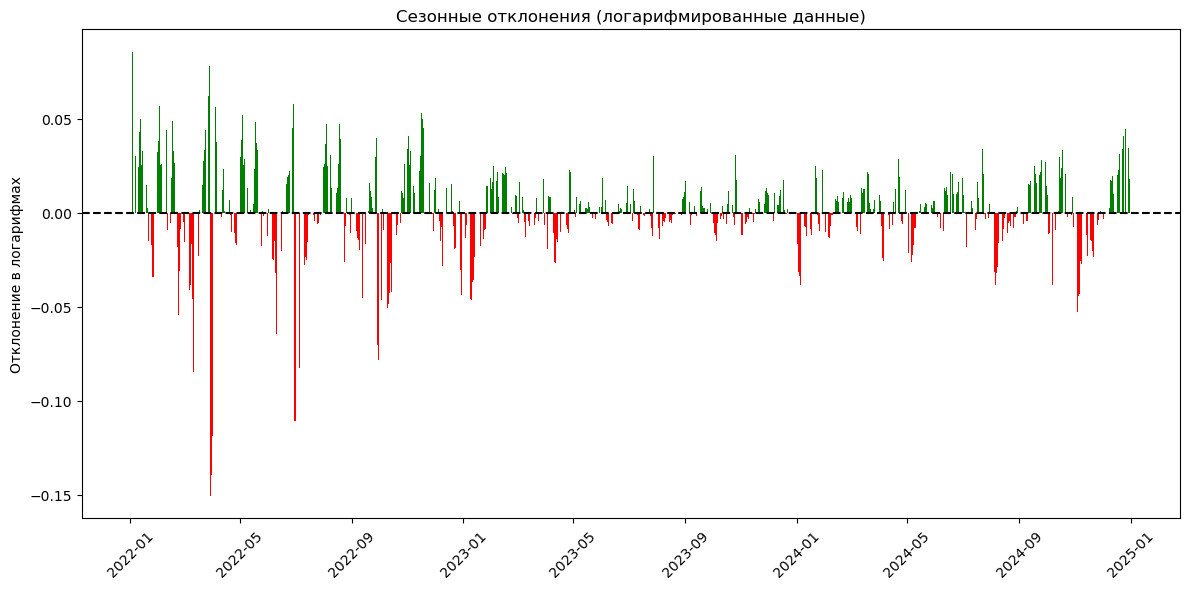

In [ ]:
seasonal_df = pd.DataFrame({
    'date': data.index,
    'seasonal': res_log.seasonal
})

seasonal_df['month'] = seasonal_df['date'].dt.month
seasonal_df['half_year'] = np.where(seasonal_df['month'] <= 6, 'H1', 'H2')

# Общая статистика по знакам отклонений
neg_pos_ratio = len(seasonal_df[seasonal_df['seasonal'] < 0]) / len(seasonal_df[seasonal_df['seasonal'] > 0])
print(f'Соотношение негативных/позитивных периодов: {neg_pos_ratio:.2f}')

# Анализ по полугодиям
h1_stats = seasonal_df[seasonal_df['half_year'] == 'H1']['seasonal'].describe()
h2_stats = seasonal_df[seasonal_df['half_year'] == 'H2']['seasonal'].describe()
print('\nСтатистика для первого полугодия (H1):')
print(h1_stats)
print('\nСтатистика для второго полугодия (H2):')
print(h2_stats)

# Проверка середины года (июнь-сентябрь)
mid_year = seasonal_df[seasonal_df['month'].between(6,9)]
mid_year_neg = mid_year[mid_year['seasonal'] < 0]
print(f'\nВ июне-сентябре {len(mid_year_neg)} из {len(mid_year)} периодов имеют негативные отклонения')

# Визуализация
plt.figure(figsize=(12,6))
plt.bar(seasonal_df['date'], seasonal_df['seasonal'],
        color=np.where(seasonal_df['seasonal'] < 0, 'red', 'green'))
plt.axhline(0, color='black', linestyle='--')
plt.title('Сезонные отклонения (логарифмированные данные)')
plt.ylabel('Отклонение в логарифмах')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1400x600 with 0 Axes>

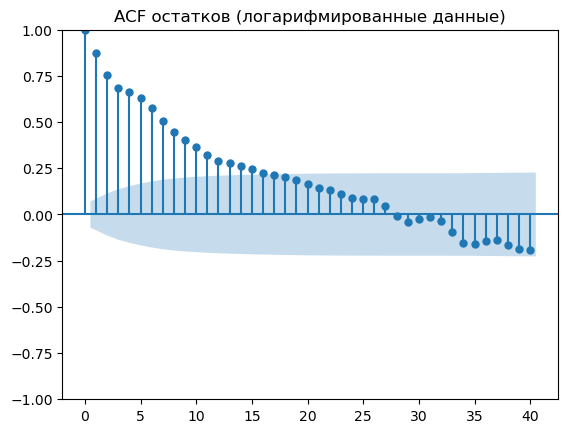

In [ ]:
plt.figure(figsize=(14, 6))
plot_acf(res_log.resid, lags=40, alpha=0.05, title='ACF остатков (логарифмированные данные)')
plt.show()
plt.show()

<Figure size 1400x600 with 0 Axes>

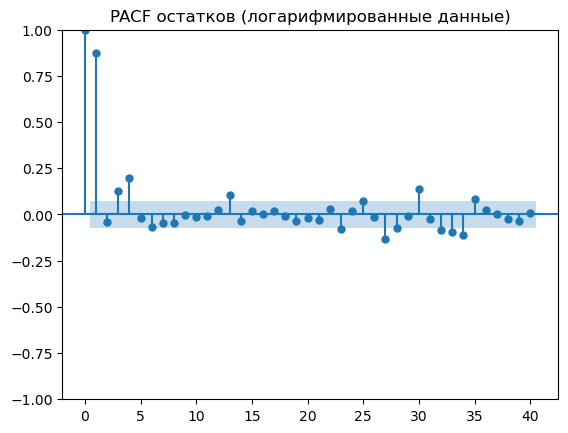

In [ ]:
plt.figure(figsize=(14, 6))
plot_pacf(res_log.resid, lags=40, alpha=0.05, title='PACF остатков (логарифмированные данные)')
plt.show()

Тест Ирвина (локальный): 58 выбросов
Адаптивный Z-score: 6 выбросов


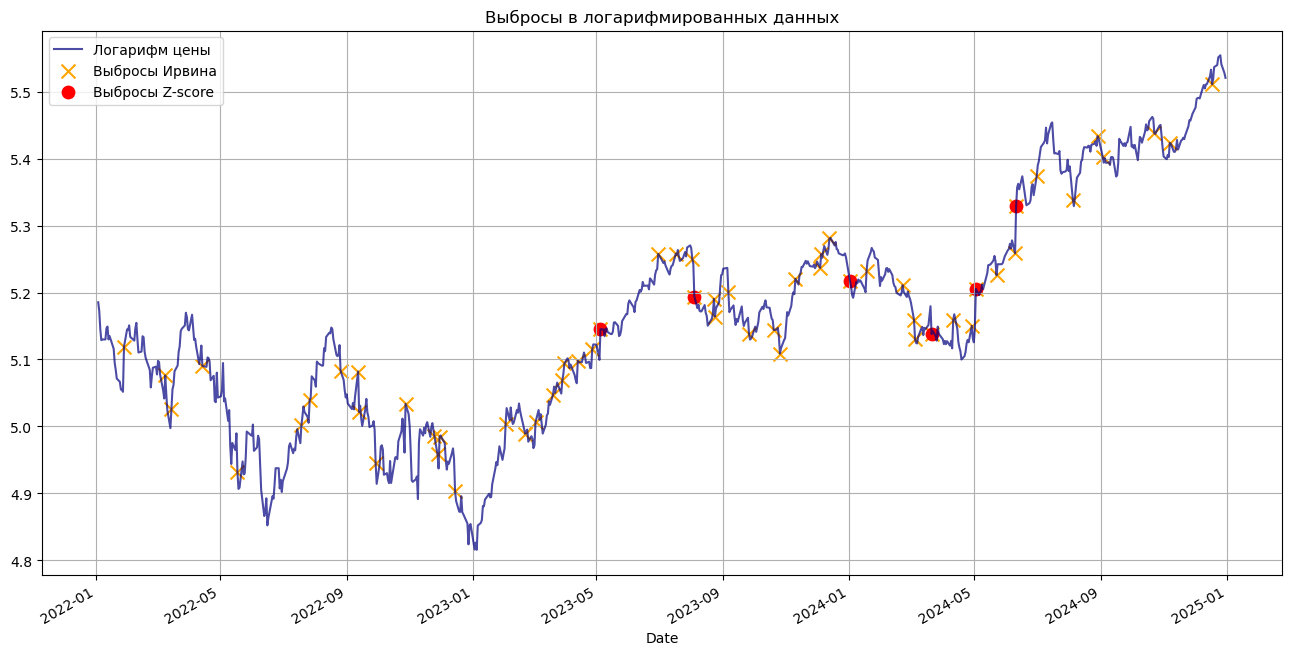

In [ ]:
def irwin_test_local(series, window=10, threshold=3.0):
    diffs = series.diff().abs()
    rolling_std = diffs.rolling(window=window).std()
    return diffs > (threshold * rolling_std)

def adaptive_zscore(series, window=30, threshold=3.5):
    price_diff = series.diff().abs()
    rolling_mean = price_diff.rolling(window=window).mean()
    rolling_std = price_diff.rolling(window=window).std()
    z_scores = (price_diff - rolling_mean) / rolling_std
    return abs(z_scores) > threshold

# Применяем к логарифмированным данным
outliers_irwin = irwin_test_local(data['Log_Close'])
outliers_z = adaptive_zscore(data['Log_Close'])

print(f"Тест Ирвина (локальный): {outliers_irwin.sum()} выбросов")
print(f"Адаптивный Z-score: {outliers_z.sum()} выбросов")

plt.figure(figsize=(16, 8))
data['Log_Close'].plot(color='navy', label='Логарифм цены', alpha=0.7)
plt.scatter(data[outliers_irwin].index, data[outliers_irwin]['Log_Close'],
            color='orange', marker='x', s=100, label='Выбросы Ирвина')
plt.scatter(data[outliers_z].index, data[outliers_z]['Log_Close'],
            color='red', s=80, label='Выбросы Z-score')
plt.title('Выбросы в логарифмированных данных')
plt.legend()
plt.grid(True)
plt.show()

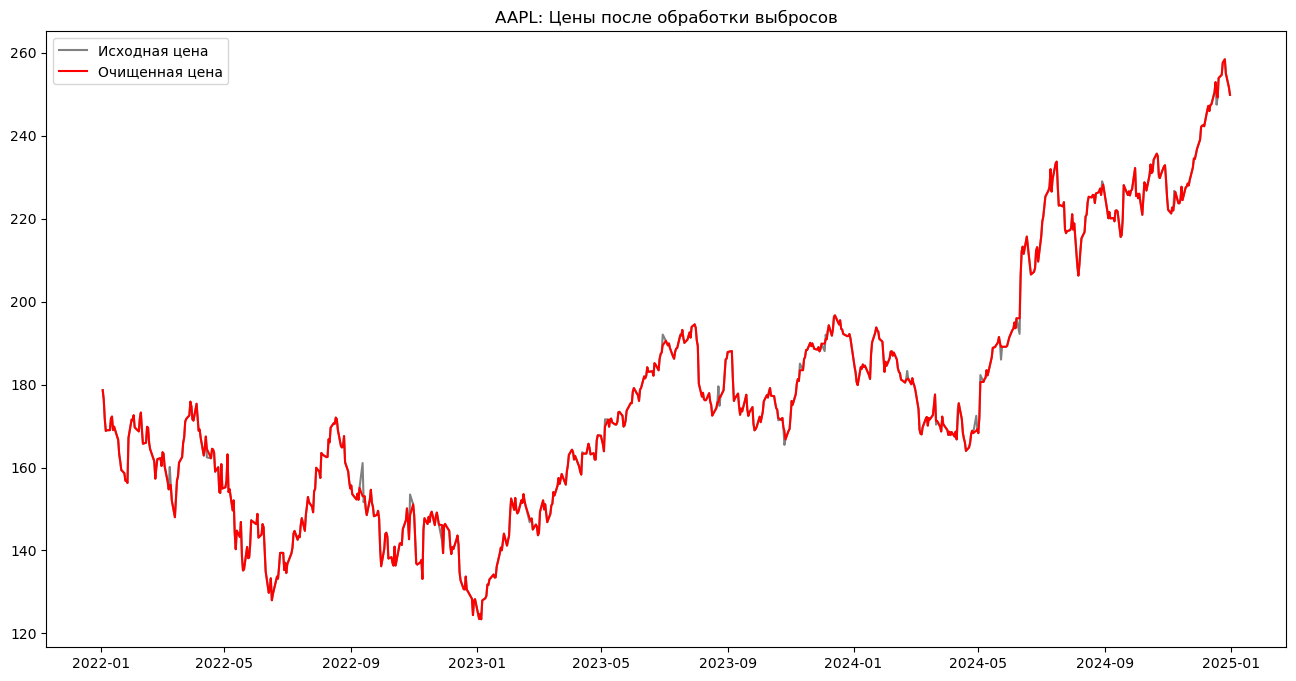

In [ ]:
def handle_outliers(series, outliers, method='smoothing', window=5):
    cleaned = series.copy()
    if method == 'smoothing':
        rolling_median = series.rolling(window=window, center=True, min_periods=1).median()
        cleaned[outliers] = rolling_median[outliers]
    elif method == 'interpolation':
        cleaned[outliers] = np.nan
        cleaned = cleaned.interpolate()
    return cleaned

combined_outliers = outliers_irwin | outliers_z
cleaned_log_prices = handle_outliers(data['Log_Close'], combined_outliers)

# Преобразуем обратно в обычные цены
data['Cleaned_Close'] = np.exp(cleaned_log_prices)

plt.figure(figsize=(16, 8))
plt.plot(data.index, np.exp(data['Log_Close']), color='gray', label='Исходная цена')
plt.plot(data.index, data['Cleaned_Close'], color='red', label='Очищенная цена')
plt.title('AAPL: Цены после обработки выбросов')
plt.legend()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Очищенные логарифмированные данные
log_series = data['Log_Close'].copy()

# Подготовка для LSTM (нормализация + окна)
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(log_series.values.reshape(-1, 1))

def create_dataset(data, window_size=30):
    X, y = [], []
    for i in range(len(data)-window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X), np.array(y)

X, y = create_dataset(scaled_data, window_size=30)

# 3. Разделение на train/test (80/20)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
# Для ARIMA (используем логарифмированные данные без дифференцирования)
log_series.to_csv("AAPL_arima_ready.csv", header=['Log_Close'])

# Для LSTM
np.savez("AAPL_lstm_ready.npz",
         X_train=X_train, X_test=X_test,
         y_train=y_train, y_test=y_test)

print("Данные сохранены:")
print("- AAPL_arima_ready.csv (логарифмированные цены)")
print("- AAPL_lstm_ready.npz (данные для LSTM)")

Данные сохранены:
- AAPL_arima_ready.csv (логарифмированные цены)
- AAPL_lstm_ready.npz (данные для LSTM)


### Блок 1: Импорт библиотек и загрузка данных


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings

# Загрузка подготовленных данных
log_series = pd.read_csv('AAPL_arima_ready.csv', index_col=0, parse_dates=True)['Log_Close']
lstm_data = np.load('AAPL_lstm_ready.npz')
X_train, X_test, y_train, y_test = lstm_data['X_train'], lstm_data['X_test'], lstm_data['y_train'], lstm_data['y_test']

# test_series для визуализации
test_series = log_series.iloc[-len(y_test):].copy()

In [ ]:
log_series.index = pd.date_range(start="2022-01-01", periods=len(log_series), freq="D")  # Example index

model_auto_arima = auto_arima(
    log_series,
    seasonal=True,
    m=68,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    information_criterion='aic'
)

test_size = len(y_test)
arima_pred_log = model_auto_arima.predict(n_periods=test_size)
arima_pred = np.exp(arima_pred_log)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[68] intercept   : AIC=-3979.338, Time=8.22 sec
 ARIMA(0,1,0)(0,0,0)[68] intercept   : AIC=-3987.682, Time=0.07 sec
 ARIMA(1,1,0)(1,0,0)[68] intercept   : AIC=-3984.555, Time=3.17 sec
 ARIMA(0,1,1)(0,0,1)[68] intercept   : AIC=-3984.522, Time=2.41 sec
 ARIMA(0,1,0)(0,0,0)[68]             : AIC=-3989.166, Time=0.05 sec
 ARIMA(0,1,0)(1,0,0)[68] intercept   : AIC=-3986.412, Time=2.19 sec
 ARIMA(0,1,0)(0,0,1)[68] intercept   : AIC=-3986.427, Time=5.19 sec
 ARIMA(0,1,0)(1,0,1)[68] intercept   : AIC=-3984.433, Time=6.14 sec
 ARIMA(1,1,0)(0,0,0)[68] intercept   : AIC=-3985.897, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[68] intercept   : AIC=-3985.903, Time=0.14 sec
 ARIMA(1,1,1)(0,0,0)[68] intercept   : AIC=-3983.948, Time=0.10 sec

Best model:  ARIMA(0,1,0)(0,0,0)[68]          
Total fit time: 27.760 seconds


In [ ]:
lstm_model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

lstm_model.compile(optimizer='adam', loss='mse')

early_stopping = EarlyStopping(monitor='val_loss',
                              patience=10,
                              restore_best_weights=True)

history = lstm_model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

lstm_pred_scaled = lstm_model.predict(X_test)

lstm_pred_log = scaler.inverse_transform(lstm_pred_scaled).flatten()
lstm_pred = np.exp(lstm_pred_log)

Epoch 1/100


C:\Users\pppp\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - loss: 0.0533 - val_loss: 0.0130
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0069 - val_loss: 0.0066
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0054 - val_loss: 0.0022
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0042 - val_loss: 0.0016
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0036 - val_loss: 0.0015
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0036 - val_loss: 0.0027
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0033 - val_loss: 0.0013
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0033 - val_loss: 0.0019
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0031 - val_loss: 0.0013
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0028 - val_loss: 0.0013
Epoch 11/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0028 - val_loss: 0.0020
Epoch 12/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0

In [ ]:
# Наивная модель (последнее значение)
last_value = np.exp(log_series.iloc[-1])
naive_pred = np.full(test_size, last_value)

# Подготовка фактических значений для сравнения
test_prices_log = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
test_prices = np.exp(test_prices_log)

min_len = min(len(arima_pred), len(lstm_pred), len(naive_pred), len(test_prices))
test_prices_cut = test_prices[:min_len]
arima_pred_cut = arima_pred[:min_len]
lstm_pred_cut = lstm_pred[:min_len]
naive_pred_cut = naive_pred[:min_len]

# Функция для расчета метрик
def calculate_metrics(true, pred):
    return {
        'RMSE': np.sqrt(mean_squared_error(true, pred)),
        'MAE': mean_absolute_error(true, pred),
        'R²': r2_score(true, pred)
    }

metrics = {
    'Naive': calculate_metrics(test_prices_cut, naive_pred_cut),
    'ARIMA': {
        **calculate_metrics(test_prices_cut, arima_pred_cut),
        'AIC': model_auto_arima.aic(),
        'BIC': model_auto_arima.bic()
    },
    'LSTM': calculate_metrics(test_prices_cut, lstm_pred_cut)
}

print("\nСравнение моделей:")
metrics_df = pd.DataFrame(metrics).T
print(metrics_df)


Сравнение моделей:
            RMSE        MAE        R²          AIC          BIC
Naive  26.770447  24.180514 -3.605040          NaN          NaN
ARIMA  26.770447  24.180514 -3.605040 -3989.166228 -3984.543492
LSTM    3.760974   2.888428  0.909109          NaN          NaN


In [ ]:
# Тест на зашумленность данных
def add_gaussian_noise(data, noise_level=0.1):
    """Добавляет гауссов шум к данным"""
    std_dev = np.std(data) * noise_level
    noise = np.random.normal(loc=0, scale=std_dev, size=data.shape)
    return data + noise

# Добавление шума к обучающим данным LSTM
X_train_noisy = add_gaussian_noise(X_train)
y_train_noisy = add_gaussian_noise(y_train)

# Пересоздание и обучение LSTM на зашумленных данных
lstm_model_noisy = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

lstm_model_noisy.compile(optimizer='adam', loss='mse')

history_noisy = lstm_model_noisy.fit(
    X_train_noisy,
    y_train_noisy,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

lstm_pred_scaled_noisy = lstm_model_noisy.predict(X_test)
lstm_pred_log_noisy = scaler.inverse_transform(lstm_pred_scaled_noisy).flatten()
lstm_pred_noisy = np.exp(lstm_pred_log_noisy)

lstm_pred_noisy_cut = lstm_pred_noisy[:min_len]

metrics['LSTM (noisy)'] = calculate_metrics(test_prices_cut, lstm_pred_noisy_cut)


Epoch 1/100


C:\Users\pppp\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 0.0875 - val_loss: 0.0140
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0102 - val_loss: 0.0029
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0077 - val_loss: 0.0053
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0053 - val_loss: 0.0039
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0051 - val_loss: 0.0024
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0044 - val_loss: 0.0020
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0044 - val_loss: 0.0016
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0036 - val_loss: 0.0017
Epoch 9/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0036 - val_loss: 0.0016
Epoch 10/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0037 - val_loss: 0.0015
Epoch 11/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0043 - val_loss: 0.0015
Epoch 12/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0

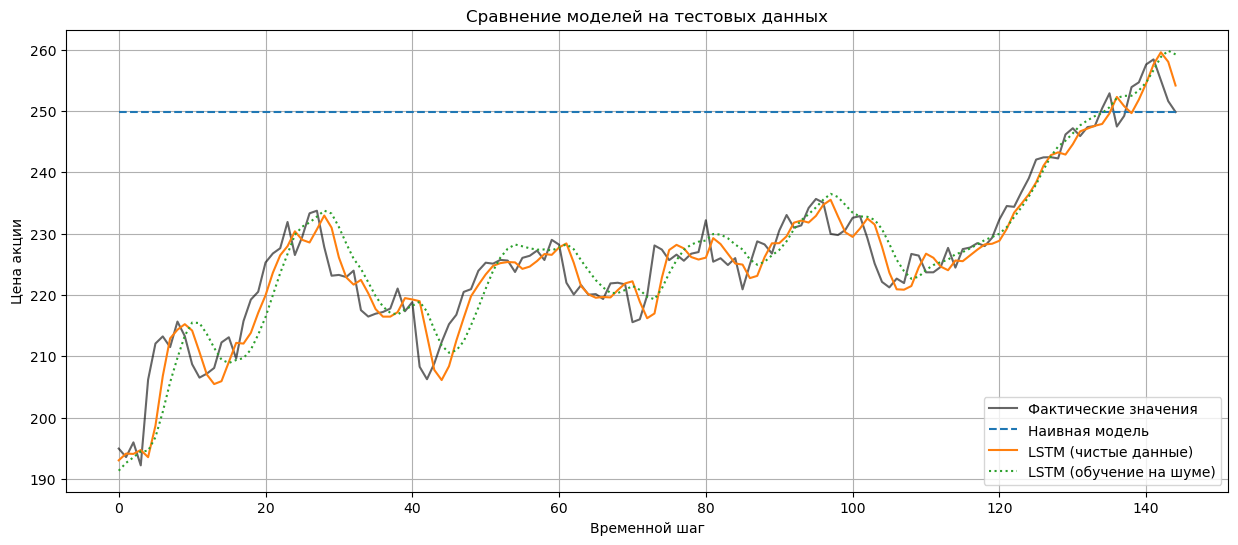


Сравнение моделей (с тестом на зашумленность):
                   RMSE        MAE        R²          AIC          BIC
Naive         26.770447  24.180514 -3.605040          NaN          NaN
ARIMA         26.770447  24.180514 -3.605040 -3989.166228 -3984.543492
LSTM           3.760974   2.888428  0.909109          NaN          NaN
LSTM (noisy)   4.643915   3.565297  0.861423          NaN          NaN

Анализ устойчивости:
- LSTM на чистых данных MAE: 2.8884
- LSTM на зашумленных данных MAE: 3.5653
- Влияние шума: 23.43% увеличения ошибки
Вывод: LSTM умеренно чувствительна к шуму


In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(test_prices_cut, label='Фактические значения', color='black', alpha=0.6)
plt.plot(naive_pred_cut, label='Наивная модель', linestyle='--')
plt.plot(lstm_pred_cut, label='LSTM (чистые данные)')
plt.plot(lstm_pred_noisy_cut, label='LSTM (обучение на шуме)', linestyle=':')
plt.title('Сравнение моделей на тестовых данных')
plt.xlabel('Временной шаг')
plt.ylabel('Цена акции')
plt.legend()
plt.grid(True)
plt.show()

# Вывод обновленных метрик
print("\nСравнение моделей (с тестом на зашумленность):")
metrics_df = pd.DataFrame(metrics).T
print(metrics_df)

# Анализ устойчивости LSTM
lstm_clean_mae = metrics['LSTM']['MAE']
lstm_noisy_mae = metrics['LSTM (noisy)']['MAE']
noise_impact = (lstm_noisy_mae - lstm_clean_mae) / lstm_clean_mae * 100

print(f"\nАнализ устойчивости:")
print(f"- LSTM на чистых данных MAE: {lstm_clean_mae:.4f}")
print(f"- LSTM на зашумленных данных MAE: {lstm_noisy_mae:.4f}")
print(f"- Влияние шума: {noise_impact:.2f}% увеличения ошибки")

if noise_impact < 15:
    print("Вывод: LSTM демонстрирует хорошую устойчивость к шуму")
elif noise_impact < 30:
    print("Вывод: LSTM умеренно чувствительна к шуму")
else:
    print("Вывод: LSTM сильно теряет точность при наличии шума")

In [ ]:
# Тест на недостаток данных с усреднением по 5 прогонам
train_sizes = [1.0, 0.8, 0.6, 0.4, 0.2]
n_runs = 5
all_results = []

for run in range(n_runs):
    print(f"\nПрогон {run+1}/{n_runs}")
    run_results = []

    for size in train_sizes:
        n_samples = int(len(X_train) * size)
        X_train_sub = X_train[:n_samples]
        y_train_sub = y_train[:n_samples]

        lstm_model_sub = Sequential([
            LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], 1)),
            Dropout(0.2),
            LSTM(64, return_sequences=False),
            Dropout(0.2),
            Dense(1)
        ])
        lstm_model_sub.compile(optimizer='adam', loss='mse')

        lstm_model_sub.fit(
            X_train_sub, y_train_sub,
            epochs=100,
            batch_size=32,
            validation_split=0.2,
            callbacks=[early_stopping],
            verbose=0
        )

        lstm_pred = lstm_model_sub.predict(X_test)
        lstm_pred_log = scaler.inverse_transform(lstm_pred).flatten()
        lstm_pred_price = np.exp(lstm_pred_log)[:len(y_test)]

        mae_lstm = mean_absolute_error(test_prices_cut, lstm_pred_price[:min_len])
        mae_naive = metrics['Naive']['MAE']

        run_results.append({
            'train_size': size,
            'samples': n_samples,
            'LSTM_MAE': mae_lstm,
            'Naive_MAE': mae_naive,
            'advantage': (mae_naive - mae_lstm) / mae_naive * 100
        })

    all_results.append(run_results)

# Усреднение результатов
avg_results = []
for i, size in enumerate(train_sizes):
    lstm_mae_avg = np.mean([r[i]['LSTM_MAE'] for r in all_results])
    advantage_avg = np.mean([r[i]['advantage'] for r in all_results])

    avg_results.append({
        'train_size': size,
        'samples': all_results[0][i]['samples'],
        'LSTM_MAE_avg': lstm_mae_avg,
        'Naive_MAE': all_results[0][i]['Naive_MAE'],  # одинаковое для всех прогонов
        'advantage_avg': advantage_avg,
        'LSTM_better': lstm_mae_avg < all_results[0][i]['Naive_MAE']
    })

results_df = pd.DataFrame(avg_results)
print("\nУсредненные результаты после 5 прогонов:")
print(results_df[['train_size', 'samples', 'LSTM_MAE_avg', 'Naive_MAE', 'advantage_avg', 'LSTM_better']])

# Анализ стабильности
lstm_mae_std = [np.std([r[i]['LSTM_MAE'] for r in all_results]) for i in range(len(train_sizes))]
results_df['LSTM_MAE_std'] = lstm_mae_std

print("\nСтандартное отклонение MAE LSTM по прогонам:")
print(results_df[['train_size', 'LSTM_MAE_std']])

# Определение точки безубыточности
break_even_point = results_df[results_df['LSTM_better'] == False].iloc[0] if False in results_df['LSTM_better'].values else None

if break_even_point is not None:
    print(f"\nТочка безубыточности: LSTM перестает превосходить наивную модель при {break_even_point['train_size']*100:.0f}% данных")
else:
    print("\nLSTM сохраняет преимущество даже при 20% данных")


Прогон 1/5


C:\Users\pppp\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


C:\Users\pppp\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


...

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


C:\Users\pppp\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


C:\Users\pppp\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

Усредненные результаты после 5 прогонов:
   train_size  samples  LSTM_MAE_avg  Naive_MAE  advantage_avg  LSTM_better
0         1.0      578      2.828781  24.180514      88.301403         True
1         0.8      462      3.855676  24.180514      84.054615         True
2         0.6      346      7.306570  24.180514      69.783231         True
3         0.4      231     14.982849  24.180514      38.037507         True
4         0.2      115     18.160875  24.180514      24.894589         True

Стандартное отклонение MAE LSTM по прогонам:
   train_size  LSTM_MAE_std
0         1.0      0.039902
1         0.8      0.453351
2         0.6      0.361955
3         0.4      4.578848
4         0.2      4.161352

LSTM сохраняет преимущество даже при 20% данных


In [ ]:
# Тест на устойчивость к разным кризисным ситуациям

#Массив дат для тестовой выборки
test_dates = log_series.index[-len(y_test):]

volatility = log_series.rolling(window=63).std()

#Определение порога
volatility_threshold = volatility.quantile(0.75)

# Разделение данных на периоды
high_vol_mask = volatility > volatility_threshold
low_vol_mask = volatility <= volatility_threshold

# Для тестовой выборки используем только периоды с резкими/плавными ценовыми колебаниями
high_vol_test_mask = test_volatility > volatility_threshold
low_vol_test_mask = test_volatility <= volatility_threshold

# Формирование подвыборок
X_test_high_vol = X_test[high_vol_test_mask]
y_test_high_vol = y_test[high_vol_test_mask]

X_test_low_vol = X_test[low_vol_test_mask]
y_test_low_vol = y_test[low_vol_test_mask]

# Прогнозирование и оценка
def evaluate_volatility_subset(X_subset, y_subset, model, scaler):
    if len(X_subset) == 0:
        return None

    pred_scaled = model.predict(X_subset)
    pred_log = scaler.inverse_transform(pred_scaled).flatten()
    pred_prices = np.exp(pred_log)

    true_log = scaler.inverse_transform(y_subset.reshape(-1, 1)).flatten()
    true_prices = np.exp(true_log)

    return {
        'MAE': mean_absolute_error(true_prices, pred_prices),
        'RMSE': np.sqrt(mean_squared_error(true_prices, pred_prices)),
        'R2': r2_score(true_prices, pred_prices),
        'samples': len(X_subset)
    }

# Оценка на выборках с высокими колебаниями
high_vol_metrics = evaluate_volatility_subset(X_test_high_vol, y_test_high_vol, lstm_model, scaler)
print("\nМетрики в периоды высокой волатильности:")
print(f"Количество образцов: {high_vol_metrics['samples']}")
print(f"MAE: {high_vol_metrics['MAE']:.4f}")
print(f"RMSE: {high_vol_metrics['RMSE']:.4f}")
print(f"R²: {high_vol_metrics['R2']:.4f}")

# Оценка на выборках с низкими колебаниями
low_vol_metrics = evaluate_volatility_subset(X_test_low_vol, y_test_low_vol, lstm_model, scaler)
print("\nМетрики в периоды низкой волатильности:")
print(f"Количество образцов: {low_vol_metrics['samples']}")
print(f"MAE: {low_vol_metrics['MAE']:.4f}")
print(f"RMSE: {low_vol_metrics['RMSE']:.4f}")
print(f"R²: {low_vol_metrics['R2']:.4f}")

# Сравнение с наивной моделью
if high_vol_metrics and low_vol_metrics:
    naive_high_vol = mean_absolute_error(
        np.exp(scaler.inverse_transform(y_test_high_vol).flatten()),
        np.full(len(y_test_high_vol), np.exp(log_series.iloc[-1]))
    )

    naive_low_vol = mean_absolute_error(
        np.exp(scaler.inverse_transform(y_test_low_vol).flatten()),
        np.full(len(y_test_low_vol), np.exp(log_series.iloc[-1]))
    )

    print("\nСравнение с наивной моделью:")
    print(f"LSTM преимущество в высокой волатильности: {(naive_high_vol - high_vol_metrics['MAE'])/naive_high_vol*100:.2f}%")
    print(f"LSTM преимущество в низкой волатильности: {(naive_low_vol - low_vol_metrics['MAE'])/naive_low_vol*100:.2f}%")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

Метрики в периоды высокой волатильности:
Количество образцов: 47
MAE: 3.3492
RMSE: 4.0813
R²: 0.6909
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

Метрики в периоды низкой волатильности:
Количество образцов: 98
MAE: 2.6674
RMSE: 3.5972
R²: 0.9221

Сравнение с наивной моделью:
LSTM преимущество в высокой волатильности: 89.21%
LSTM преимущество в низкой волатильности: 87.23%
